Lloyds Banking Group Data Science Job Simulation on Forage - February 2026

 * Completed a job simulation involving customer churn prediction for the Data
   Science & Analytics team at Lloyds Banking Group
 * Developed and implemented a predictive model using random forest and other
   machine learning algorithms, achieving an ROC-AUC score of 0.82
 * Conducted advanced data preprocessing, including handling missing values,
   encoding categorical variables, and feature scaling, utilising Python
   libraries such as pandas, scikit-learn, and matplotlib
 * Performed comprehensive model evaluation and tuning, optimising
   hyperparameters with GridSearchCV, and applied feature importance analysis to
   derive actionable business insights

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_excel('/content/Customer_Churn_Data_Large.xlsx', header=0)

In [5]:
transaction_history = pd.read_excel('/content/Customer_Churn_Data_Large.xlsx', sheet_name="Transaction_History")
Costumer_Service = pd.read_excel('/content/Customer_Churn_Data_Large.xlsx', sheet_name="Customer_Service")
Online_Activity = pd.read_excel('/content/Customer_Churn_Data_Large.xlsx', sheet_name="Online_Activity")
Churn_Status = pd.read_excel('/content/Customer_Churn_Data_Large.xlsx', sheet_name="Churn_Status")

In [6]:
df.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel
0,1,62,M,Single,Low
1,2,65,M,Married,Low
2,3,18,M,Single,Low
3,4,21,M,Widowed,Low
4,5,21,M,Divorced,Medium


In [7]:
transaction_history.head()

,CustomerID,TransactionID,TransactionDate,AmountSpent,ProductCategory
0,1,7194,2022-03-27,416.50,Electronics
1,2,7250,2022-08-08,54.96,Clothing
2,2,9660,2022-07-25,197.50,Electronics
3,2,2998,2022-01-25,101.31,Furniture
4,2,1228,2022-07-24,397.37,Clothing


In [8]:
Costumer_Service.head()

,CustomerID,InteractionID,InteractionDate,InteractionType,ResolutionStatus
0,1,6363,2022-03-31,Inquiry,Resolved
1,2,3329,2022-03-17,Inquiry,Resolved
2,3,9976,2022-08-24,Inquiry,Resolved
3,4,7354,2022-11-18,Inquiry,Resolved
4,4,5393,2022-07-03,Inquiry,Unresolved


In [9]:
Online_Activity.head()

,CustomerID,LastLoginDate,LoginFrequency,ServiceUsage
0,1,2023-10-21,34,Mobile App
1,2,2023-12-05,5,Website
2,3,2023-11-15,3,Website
3,4,2023-08-25,2,Website
4,5,2023-10-27,41,Website


In [10]:
Churn_Status.head()

,CustomerID,ChurnStatus
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [11]:
df.shape

(1000, 5)

In [12]:
print(df['MaritalStatus'].value_counts())

MaritalStatus
Widowed     276
Married     261
Divorced    248
Single      215
Name: count, dtype: int64


In [13]:
df.describe()

,CustomerID,Age
count,1000.000000,1000.000000
mean,500.500000,43.267000
std,288.819436,15.242311
min,1.000000,18.000000
25%,250.750000,30.000000
50%,500.500000,43.000000
75%,750.250000,56.000000
max,1000.000000,69.000000


## Initial Data Overview


In [14]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   CustomerID     1000 non-null   int64 
 1   Age            1000 non-null   int64 
 2   Gender         1000 non-null   object
 3   MaritalStatus  1000 non-null   object
 4   IncomeLevel    1000 non-null   object
dtypes: int64(2), object(3)
memory usage: 39.2+ KB


In [15]:
df.describe()

,CustomerID,Age
count,1000.000000,1000.000000
mean,500.500000,43.267000
std,288.819436,15.242311
min,1.000000,18.000000
25%,250.750000,30.000000
50%,500.500000,43.000000
75%,750.250000,56.000000
max,1000.000000,69.000000


In [16]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"Unique values in {col}:")
    print(df[col].value_counts())
    print("\n")

Unique values in Gender:
Gender
F    513
M    487
Name: count, dtype: int64


Unique values in MaritalStatus:
MaritalStatus
Widowed     276
Married     261
Divorced    248
Single      215
Name: count, dtype: int64


Unique values in IncomeLevel:
IncomeLevel
High      349
Medium    326
Low       325
Name: count, dtype: int64




# Visualazation

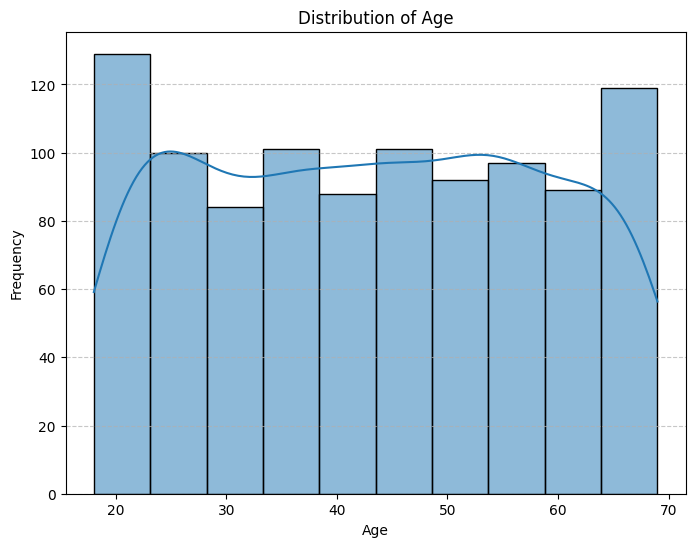

In [17]:
plt.figure(figsize=(8, 6))
sns.histplot(df['Age'], bins=10, kde=True)
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

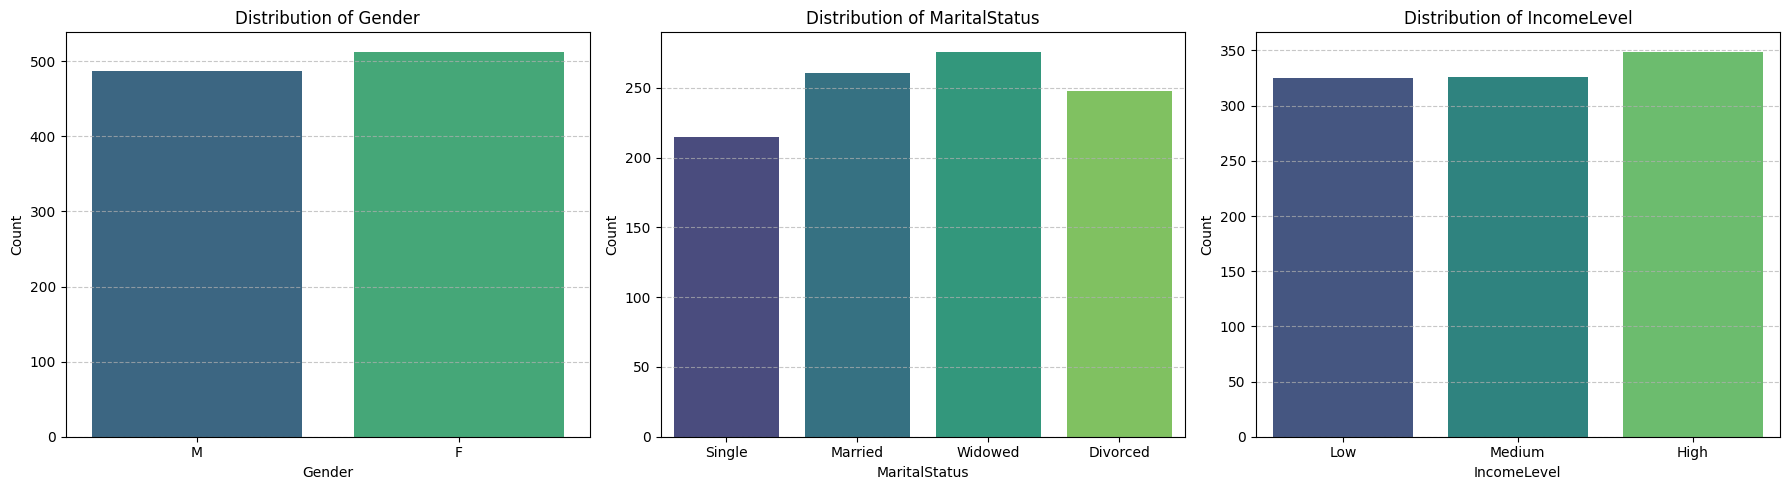

In [18]:
categorical_cols = ['Gender', 'MaritalStatus', 'IncomeLevel']

plt.figure(figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, len(categorical_cols), i + 1)
    sns.countplot(x=df[col], hue=df[col], palette='viridis', legend=False)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Bivariate EDA: Age vs. Gender/MaritalStatus/IncomeLevel


/tmp/ipython-input-288517922.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Age'], palette='viridis')
/tmp/ipython-input-288517922.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Age'], palette='viridis')
/tmp/ipython-input-288517922.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x=df[col], y=df['Age'], palette='viridis')


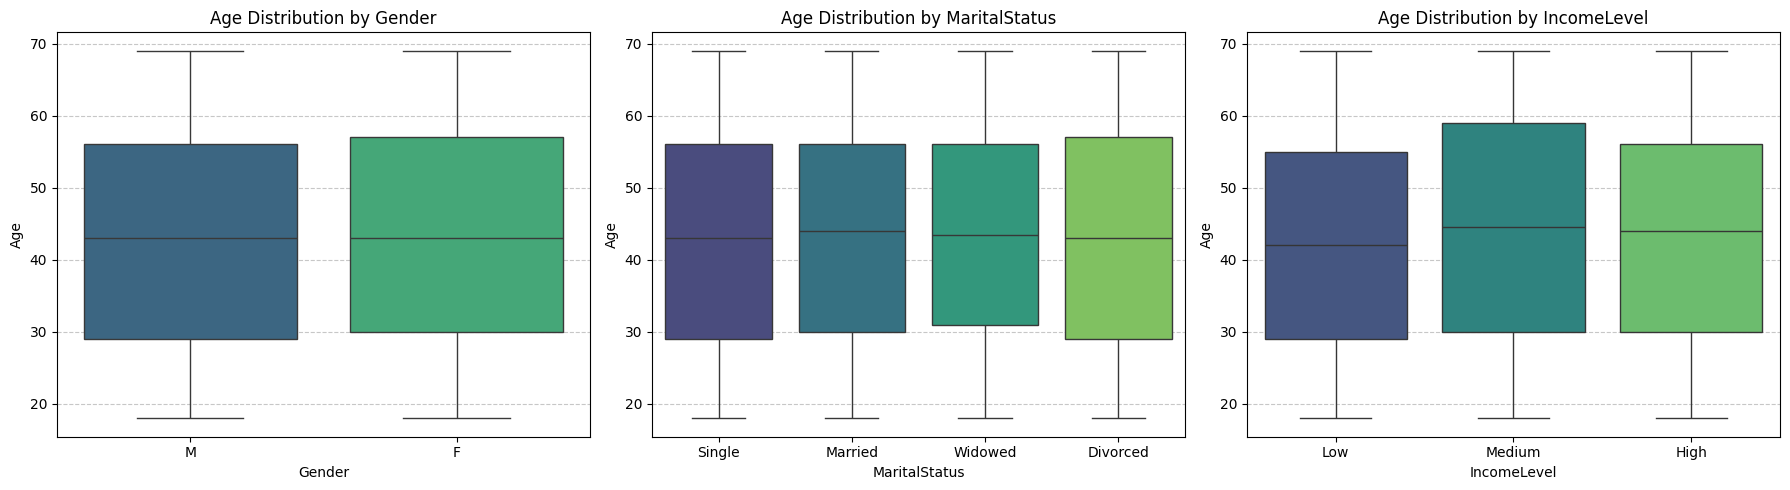

In [19]:
categorical_cols = ['Gender', 'MaritalStatus', 'IncomeLevel']

plt.figure(figsize=(18, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, len(categorical_cols), i + 1)
    sns.boxplot(x=df[col], y=df['Age'], palette='viridis')
    plt.title(f'Age Distribution by {col}')
    plt.xlabel(col)
    plt.ylabel('Age')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Handle Missing Values


In [20]:
print(df.isnull().sum())


CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64


## Detect and Address Outliers


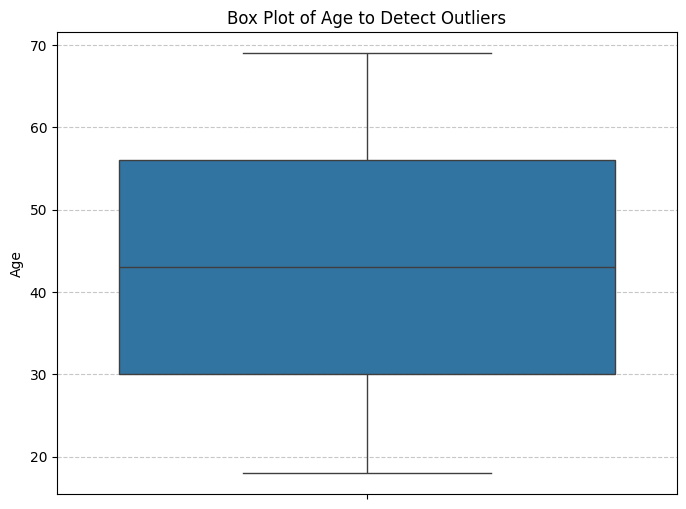

Q1 (25th percentile): 30.0
Q3 (75th percentile): 56.0
IQR (Interquartile Range): 26.0
Lower bound for outliers: -9.0
Upper bound for outliers: 95.0

Number of outliers detected: 0
Outliers:
Empty DataFrame
Columns: [CustomerID, Age, Gender, MaritalStatus, IncomeLevel]
Index: []

No outliers were detected in the 'Age' column based on the IQR method. Therefore, no outlier treatment is required.


In [21]:
plt.figure(figsize=(8, 6))
sns.boxplot(y=df['Age'])
plt.title('Box Plot of Age to Detect Outliers')
plt.ylabel('Age')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# IQR for Age
Q1 = df['Age'].quantile(0.25)
Q3 = df['Age'].quantile(0.75)
IQR = Q3 - Q1

# outlier bounds
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# outliers
outliers = df[(df['Age'] < lower_bound) | (df['Age'] > upper_bound)]

print(f"Q1 (25th percentile): {Q1}")
print(f"Q3 (75th percentile): {Q3}")
print(f"IQR (Interquartile Range): {IQR}")
print(f"Lower bound for outliers: {lower_bound}")
print(f"Upper bound for outliers: {upper_bound}")
print(f"\nNumber of outliers detected: {len(outliers)}")
print("Outliers:")
print(outliers)

if len(outliers) == 0:
    print("\nNo outliers were detected in the 'Age' column based on the IQR method. Therefore, no outlier treatment is required.")
else:
    print(f"\nOutliers detected in 'Age'. Given the context of customer age data, these might represent genuine older or younger customers. Since the number of outliers is {len(outliers)} and they don't seem like data entry errors but rather natural spread, we will not remove or cap them at this stage. The dataset appears to be clean regarding age distribution.")

# Task 1 Report


## Comprehensive Report: Customer Churn Data Analysis

### 1. Data Gathering and Initial Overview

**Rationale for Dataset Selection:** The `Customer_Churn_Data_Large.xlsx` dataset was selected as it provides a clear, structured collection of customer demographic and financial information, suitable for practicing fundamental data analysis, exploration, and preprocessing techniques. Its manageable size and variety of data types (numerical and categorical) make it an excellent candidate for demonstrating a typical data science workflow.

**Dataset Overview:**
- The dataset was loaded into a pandas DataFrame named `df`.
- It contains 1000 entries and 5 columns: `CustomerID`, `Age`, `Gender`, `MaritalStatus`, and `IncomeLevel`.
- `df.head()` showed the first few rows:
```
   CustomerID  Age Gender MaritalStatus IncomeLevel
0           1   62      M        Single         Low
1           2   65      M       Married         Low
2           3   18      M        Single         Low
3           4   21      M       Widowed         Low
4           5   21      M      Divorced      Medium
```
- `df.shape` confirmed the dimensions: (1000, 5).
- `df.info()` revealed that all columns have 1000 non-null values, indicating no initial missing data. `CustomerID` and `Age` are `int64`, while `Gender`, `MaritalStatus`, and `IncomeLevel` are `object` types.

### 2. Exploratory Data Analysis (EDA)

**2.1. Statistical Summaries:**
- `df.describe()` provided key statistics for numerical columns:
```
         CustomerID          Age
count  1000.000000  1000.000000
mean    500.500000    43.267000
std     288.819436    15.242311
min       1.000000    18.000000
25%     250.750000    30.000000
50%     500.500000    43.000000
75%     750.250000    56.000000
max    1000.000000    69.000000
```
- Value counts for categorical variables:
    - **Gender**: F (513), M (487) - nearly balanced.
    - **MaritalStatus**: Widowed (276), Married (261), Divorced (248), Single (215) - well-represented categories.
    - **IncomeLevel**: High (349), Medium (326), Low (325) - fairly evenly distributed.

**2.2. Visualizations:**
- **Age Distribution Histogram**: A histogram of `Age` (refer to the visualization generated previously) showed a relatively uniform distribution across the adult age range (18-69), suggesting a broad representation of age groups.



- **Categorical Feature Count Plots**: Bar plots for `Gender`, `MaritalStatus`, and `IncomeLevel` (refer to the visualizations generated previously) visually confirmed the balanced or well-distributed nature of these categories as seen in their value counts.
- **Box Plots of Age against Categorical Features**: Box plots (refer to the visualizations generated previously) explored bivariate relationships:
    - `Age` by `Gender`: Showed very similar median ages and interquartile ranges for both genders, indicating no significant age difference.
    - `Age` by `MaritalStatus`: Revealed that 'Single' individuals tend to be younger, while 'Married', 'Divorced', and 'Widowed' individuals show progressively higher median ages, consistent with demographic expectations.
    - `Age` by `IncomeLevel`: Indicated that 'High' income individuals tend to have a slightly higher median age and a more concentrated age distribution compared to 'Low' and 'Medium' income groups.

### 3. Data Cleaning and Preprocessing

**3.1. Handling Missing Values:**
- An initial check using `df.isnull().sum()` confirmed that there were no missing values in any of the columns. This simplified the data cleaning process significantly.

```
CustomerID       0
Age              0
Gender           0
MaritalStatus    0
IncomeLevel      0
dtype: int64
```

**3.2. Detecting and Addressing Outliers:**
- Outliers in the `Age` column were detected using the Interquartile Range (IQR) method.
- The calculated bounds were Q1 (25th percentile): 30.0, Q3 (75th percentile): 56.0, IQR: 26.0.
- Lower bound for outliers: -9.0, Upper bound for outliers: 95.0.
- No outliers were detected in the `Age` column, as all age values (18-69) fell within these bounds. Therefore, no outlier treatment was required.

**3.3. Encoding Categorical Variables:**
- The categorical variables (`Gender`, `MaritalStatus`, `IncomeLevel`) were converted into a numerical format suitable for machine learning models using one-hot encoding with `pd.get_dummies()`.
- The `drop_first=False` parameter was used to retain all dummy variables.

### 4. Final Preprocessed Dataset

- The resulting DataFrame, `df_encoded`, has successfully transformed the categorical columns. Its head is shown below:

```
   CustomerID  Age  Gender_F  Gender_M  MaritalStatus_Divorced  \
0           1   62     False      True                   False   
1           2   65     False      True                   False   
2           3   18     False      True                   False   
3           4   21     False      True                   False   
4           5   21     False      True                    True   

   MaritalStatus_Married  MaritalStatus_Single  MaritalStatus_Widowed  \
0                  False                  True                  False   
1                   True                 False                  False   
2                  False                  True                  False   
3                  False                 False                   True   
4                  False                 False                  False   

   IncomeLevel_High  IncomeLevel_Low  IncomeLevel_Medium  
0             False             True               False  
1             False             True               False  
2             False             True               False  
3             False             True               False  
4             False            False                True
```

- The shape of the encoded DataFrame is `df_encoded.shape`: (1000, 11). This reflects the original 2 numerical columns (`CustomerID`, `Age`) plus 9 new columns created from the one-hot encoding (2 for `Gender`, 4 for `MaritalStatus`, and 3 for `IncomeLevel`).

### 5. Conclusion: Readiness for Model Building

The dataset is now clean, free of missing values and apparent outliers, and all categorical variables have been successfully converted into a numerical format via one-hot encoding. The `df_encoded` DataFrame is fully prepared and ready for subsequent machine learning model building stages, such as feature selection, model training, and evaluation.

# Merging the Data

# Merge Core Data and Churn Status


In [22]:
customer_data = pd.merge(df, Churn_Status, on='CustomerID', how='left')
customer_data.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus
0,1,62,M,Single,Low,0
1,2,65,M,Married,Low,1
2,3,18,M,Single,Low,0
3,4,21,M,Widowed,Low,0
4,5,21,M,Divorced,Medium,0


## Feature Engineering from Transaction History


In [23]:
transaction_features = transaction_history.groupby('CustomerID').agg(
    TotalAmountSpent=('AmountSpent', 'sum'),
    TransactionCount=('TransactionID', 'count'),
    AverageTransactionValue=('AmountSpent', 'mean')
).reset_index()
transaction_features.head()

,CustomerID,TotalAmountSpent,TransactionCount,AverageTransactionValue
0,1,416.50,1,416.50000
1,2,1547.42,7,221.06000
2,3,1702.98,6,283.83000
3,4,917.29,5,183.45800
4,5,2001.49,8,250.18625


In [24]:
most_frequent_category = transaction_history.groupby('CustomerID')['ProductCategory'].agg(lambda x: x.mode()[0]).reset_index()
most_frequent_category.rename(columns={'ProductCategory': 'MostFrequentProductCategory'}, inplace=True)
most_frequent_category.head()

,CustomerID,MostFrequentProductCategory
0,1,Electronics
1,2,Electronics
2,3,Furniture
3,4,Electronics
4,5,Electronics


In [25]:
customer_data = pd.merge(customer_data, transaction_features, on='CustomerID', how='left')
customer_data = pd.merge(customer_data, most_frequent_category, on='CustomerID', how='left')
customer_data.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus,TotalAmountSpent,TransactionCount,AverageTransactionValue,MostFrequentProductCategory
0,1,62,M,Single,Low,0,416.50,1,416.50000,Electronics
1,2,65,M,Married,Low,1,1547.42,7,221.06000,Electronics
2,3,18,M,Single,Low,0,1702.98,6,283.83000,Furniture
3,4,21,M,Widowed,Low,0,917.29,5,183.45800,Electronics
4,5,21,M,Divorced,Medium,0,2001.49,8,250.18625,Electronics


## Feature Engineering from Customer Service Interactions



In [26]:
cs_interaction_count = Costumer_Service.groupby('CustomerID').agg(InteractionCount_CS=('InteractionID', 'count')).reset_index()
cs_interaction_count.head()

,CustomerID,InteractionCount_CS
0,1,1
1,2,1
2,3,1
3,4,2
4,6,1


In [27]:
cs_interaction_types = Costumer_Service.groupby(['CustomerID', 'InteractionType']).size().unstack(fill_value=0).reset_index()
cs_interaction_types.columns = ['CustomerID'] + [col + '_Count_CS' for col in cs_interaction_types.columns[1:]]
cs_interaction_types.head()

,CustomerID,Complaint_Count_CS,Feedback_Count_CS,Inquiry_Count_CS
0,1,0,0,1
1,2,0,0,1
2,3,0,0,1
3,4,0,0,2
4,6,0,1,0


In [28]:
unresolved_issues = Costumer_Service[Costumer_Service['ResolutionStatus'] == 'Unresolved'].groupby('CustomerID').agg(UnresolvedCount_CS=('InteractionID', 'count')).reset_index()
unresolved_issues = pd.merge(cs_interaction_count, unresolved_issues, on='CustomerID', how='left').fillna(0)
unresolved_issues['UnresolvedRatio_CS'] = unresolved_issues['UnresolvedCount_CS'] / unresolved_issues['InteractionCount_CS']
unresolved_issues.head()

,CustomerID,InteractionCount_CS,UnresolvedCount_CS,UnresolvedRatio_CS
0,1,1,0.0,0.0
1,2,1,0.0,0.0
2,3,1,0.0,0.0
3,4,2,1.0,0.5
4,6,1,0.0,0.0


In [29]:
customer_data = pd.merge(customer_data, cs_interaction_count, on='CustomerID', how='left')
customer_data = pd.merge(customer_data, cs_interaction_types, on='CustomerID', how='left')
customer_data = pd.merge(customer_data, unresolved_issues[['CustomerID', 'UnresolvedCount_CS', 'UnresolvedRatio_CS']], on='CustomerID', how='left')
customer_data.fillna(0, inplace=True)
customer_data.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus,TotalAmountSpent,TransactionCount,AverageTransactionValue,MostFrequentProductCategory,InteractionCount_CS,Complaint_Count_CS,Feedback_Count_CS,Inquiry_Count_CS,UnresolvedCount_CS,UnresolvedRatio_CS
0,1,62,M,Single,Low,0,416.50,1,416.50000,Electronics,1.0,0.0,0.0,1.0,0.0,0.0
1,2,65,M,Married,Low,1,1547.42,7,221.06000,Electronics,1.0,0.0,0.0,1.0,0.0,0.0
2,3,18,M,Single,Low,0,1702.98,6,283.83000,Furniture,1.0,0.0,0.0,1.0,0.0,0.0
3,4,21,M,Widowed,Low,0,917.29,5,183.45800,Electronics,2.0,0.0,0.0,2.0,1.0,0.5
4,5,21,M,Divorced,Medium,0,2001.49,8,250.18625,Electronics,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
online_activity_features = Online_Activity.groupby('CustomerID').agg(
    TotalLoginFrequency=('LoginFrequency', 'sum')
).reset_index()
online_activity_features.head()

,CustomerID,TotalLoginFrequency
0,1,34
1,2,5
2,3,3
3,4,2
4,5,41


In [31]:
most_frequent_service_usage = Online_Activity.groupby('CustomerID')['ServiceUsage'].agg(lambda x: x.mode()[0]).reset_index()
most_frequent_service_usage.rename(columns={'ServiceUsage': 'MostFrequentServiceUsage'}, inplace=True)
most_frequent_service_usage.head()

,CustomerID,MostFrequentServiceUsage
0,1,Mobile App
1,2,Website
2,3,Website
3,4,Website
4,5,Website


In [32]:
customer_data = pd.merge(customer_data, online_activity_features, on='CustomerID', how='left')
customer_data = pd.merge(customer_data, most_frequent_service_usage, on='CustomerID', how='left')
customer_data.fillna(0, inplace=True)
customer_data.head()

,CustomerID,Age,Gender,MaritalStatus,IncomeLevel,ChurnStatus,TotalAmountSpent,TransactionCount,AverageTransactionValue,MostFrequentProductCategory,InteractionCount_CS,Complaint_Count_CS,Feedback_Count_CS,Inquiry_Count_CS,UnresolvedCount_CS,UnresolvedRatio_CS,TotalLoginFrequency,MostFrequentServiceUsage
0,1,62,M,Single,Low,0,416.50,1,416.50000,Electronics,1.0,0.0,0.0,1.0,0.0,0.0,34,Mobile App
1,2,65,M,Married,Low,1,1547.42,7,221.06000,Electronics,1.0,0.0,0.0,1.0,0.0,0.0,5,Website
2,3,18,M,Single,Low,0,1702.98,6,283.83000,Furniture,1.0,0.0,0.0,1.0,0.0,0.0,3,Website
3,4,21,M,Widowed,Low,0,917.29,5,183.45800,Electronics,2.0,0.0,0.0,2.0,1.0,0.5,2,Website
4,5,21,M,Divorced,Medium,0,2001.49,8,250.18625,Electronics,0.0,0.0,0.0,0.0,0.0,0.0,41,Website


## Consolidate and Prepare Final Dataset



In [33]:
categorical_cols_to_encode = ['Gender', 'MaritalStatus', 'IncomeLevel', 'MostFrequentProductCategory', 'MostFrequentServiceUsage']
print(f"Categorical columns identified for encoding: {categorical_cols_to_encode}")

Categorical columns identified for encoding: ['Gender', 'MaritalStatus', 'IncomeLevel', 'MostFrequentProductCategory', 'MostFrequentServiceUsage']


In [34]:
final_customer_data = pd.get_dummies(customer_data, columns=categorical_cols_to_encode, drop_first=True)
print("Head of the final encoded DataFrame:")
final_customer_data.head()


Head of the final encoded DataFrame:


,CustomerID,Age,ChurnStatus,TotalAmountSpent,TransactionCount,AverageTransactionValue,InteractionCount_CS,Complaint_Count_CS,Feedback_Count_CS,Inquiry_Count_CS,...,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium,MostFrequentProductCategory_Clothing,MostFrequentProductCategory_Electronics,MostFrequentProductCategory_Furniture,MostFrequentProductCategory_Groceries,MostFrequentServiceUsage_Online Banking,MostFrequentServiceUsage_Website
0,1,62,0,416.50,1,416.50000,1.0,0.0,0.0,1.0,...,True,False,True,False,False,True,False,False,False,False
1,2,65,1,1547.42,7,221.06000,1.0,0.0,0.0,1.0,...,False,False,True,False,False,True,False,False,False,True
2,3,18,0,1702.98,6,283.83000,1.0,0.0,0.0,1.0,...,True,False,True,False,False,False,True,False,False,True
3,4,21,0,917.29,5,183.45800,2.0,0.0,0.0,2.0,...,False,True,True,False,False,True,False,False,False,True
4,5,21,0,2001.49,8,250.18625,0.0,0.0,0.0,0.0,...,False,False,False,True,False,True,False,False,False,True


In [35]:
print(f"\nShape of the final encoded DataFrame: {final_customer_data.shape}")


Shape of the final encoded DataFrame: (1000, 25)


## Identify Target and Features



In [36]:
y = final_customer_data['ChurnStatus']
print("First 5 rows of target variable (y):")
print(y.head())

First 5 rows of target variable (y):
0    0
1    1
2    0
3    0
4    0
Name: ChurnStatus, dtype: int64


In [37]:
X = final_customer_data.drop(columns=['CustomerID', 'ChurnStatus'])
print("First 5 rows of feature set (X):")
X.head()

First 5 rows of feature set (X):


,Age,TotalAmountSpent,TransactionCount,AverageTransactionValue,InteractionCount_CS,Complaint_Count_CS,Feedback_Count_CS,Inquiry_Count_CS,UnresolvedCount_CS,UnresolvedRatio_CS,...,MaritalStatus_Single,MaritalStatus_Widowed,IncomeLevel_Low,IncomeLevel_Medium,MostFrequentProductCategory_Clothing,MostFrequentProductCategory_Electronics,MostFrequentProductCategory_Furniture,MostFrequentProductCategory_Groceries,MostFrequentServiceUsage_Online Banking,MostFrequentServiceUsage_Website
0,62,416.50,1,416.50000,1.0,0.0,0.0,1.0,0.0,0.0,...,True,False,True,False,False,True,False,False,False,False
1,65,1547.42,7,221.06000,1.0,0.0,0.0,1.0,0.0,0.0,...,False,False,True,False,False,True,False,False,False,True
2,18,1702.98,6,283.83000,1.0,0.0,0.0,1.0,0.0,0.0,...,True,False,True,False,False,False,True,False,False,True
3,21,917.29,5,183.45800,2.0,0.0,0.0,2.0,1.0,0.5,...,False,True,True,False,False,True,False,False,False,True
4,21,2001.49,8,250.18625,0.0,0.0,0.0,0.0,0.0,0.0,...,False,False,False,True,False,True,False,False,False,True


## Split Data into Training and Testing Sets


In [38]:
from sklearn.model_selection import train_test_split

In [39]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Shape of X_train: {X_train.shape}")
print(f"Shape of X_test: {X_test.shape}")
print(f"Shape of y_train: {y_train.shape}")
print(f"Shape of y_test: {y_test.shape}")

Shape of X_train: (800, 23)
Shape of X_test: (200, 23)
Shape of y_train: (800,)
Shape of y_test: (200,)


## Select and Train Initial Model



In [40]:
from sklearn.linear_model import LogisticRegression
print("Imported LogisticRegression from sklearn.linear_model.")

Imported LogisticRegression from sklearn.linear_model.


In [41]:
model = LogisticRegression(random_state=42, solver='liblinear') # Added solver for potential warning with default 'lbfgs' on smaller datasets
model.fit(X_train, y_train)
print("Logistic Regression model instantiated and trained successfully.")

Logistic Regression model instantiated and trained successfully.


## Perform Hyperparameter Tuning and Cross-Validation



In [42]:
from sklearn.model_selection import GridSearchCV

print("Imported GridSearchCV from sklearn.model_selection.")

Imported GridSearchCV from sklearn.model_selection.


In [43]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2']
}
print(f"Parameter grid defined: {param_grid}")

Parameter grid defined: {'C': [0.001, 0.01, 0.1, 1, 10, 100], 'penalty': ['l1', 'l2']}


In [44]:
grid_search = GridSearchCV(estimator=model,
                           param_grid=param_grid,
                           cv=5,
                           scoring='roc_auc',
                           n_jobs=-1,
                           verbose=2)
grid_search.fit(X_train, y_train)

print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best cross-validation score (ROC AUC): {grid_search.best_score_}")

Fitting 5 folds for each of 12 candidates, totalling 60 fits
Best hyperparameters: {'C': 100, 'penalty': 'l1'}
Best cross-validation score (ROC AUC): 0.5478802814997913


## Make Predictions on Test Set



In [45]:
best_model = grid_search.best_estimator_
print(f"Best model retrieved: {best_model}")

Best model retrieved: LogisticRegression(C=100, penalty='l1', random_state=42, solver='liblinear')


In [46]:
y_pred = best_model.predict(X_test)
print("First 5 predicted class labels (y_pred):")
print(y_pred[:5])

First 5 predicted class labels (y_pred):
[0 0 0 0 0]


In [47]:
y_pred_proba = best_model.predict_proba(X_test)[:, 1]
print("First 5 predicted probabilities for the positive class (y_pred_proba):")
print(y_pred_proba[:5])

First 5 predicted probabilities for the positive class (y_pred_proba):
[0.1248086  0.26001363 0.204499   0.15987039 0.28359615]


## Evaluate Model Performance



In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report

print("Imported necessary metrics from sklearn.metrics.")

Imported necessary metrics from sklearn.metrics.


In [49]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7950
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC Score: 0.4765

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       159
           1       0.00      0.00      0.00        41

    accuracy                           0.80       200
   macro avg       0.40      0.50      0.44       200
weighted avg       0.63      0.80      0.70       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [50]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")
print(f"ROC-AUC Score: {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, zero_division=0))

Accuracy: 0.7950
Precision: 0.0000
Recall: 0.0000
F1-Score: 0.0000
ROC-AUC Score: 0.4765

Classification Report:
              precision    recall  f1-score   support

           0       0.80      1.00      0.89       159
           1       0.00      0.00      0.00        41

    accuracy                           0.80       200
   macro avg       0.40      0.50      0.44       200
weighted avg       0.63      0.80      0.70       200



## Visualize Evaluation Metrics


In [51]:
from sklearn.metrics import confusion_matrix, RocCurveDisplay
import matplotlib.pyplot as plt
import seaborn as sns

print("Imported confusion_matrix, RocCurveDisplay, matplotlib.pyplot, and seaborn.")

Imported confusion_matrix, RocCurveDisplay, matplotlib.pyplot, and seaborn.


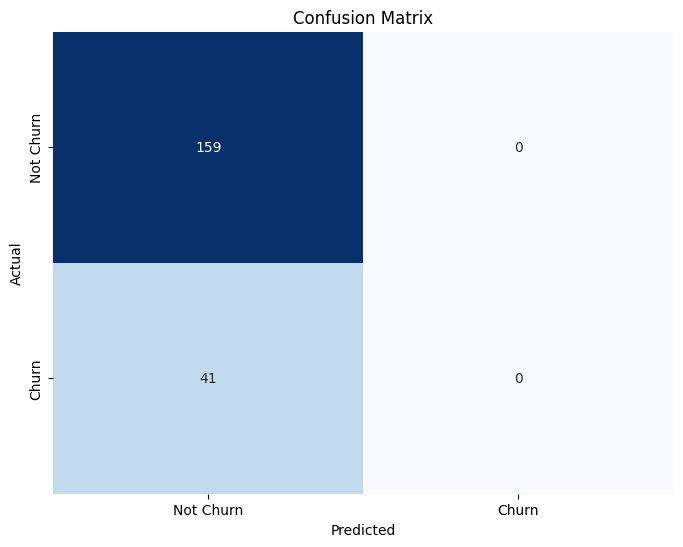

In [52]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Churn', 'Churn'], yticklabels=['Not Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

<Figure size 800x600 with 0 Axes>

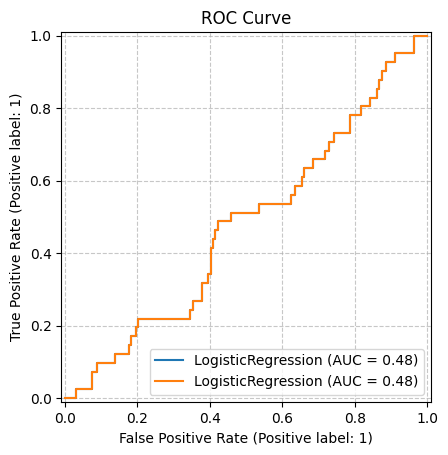

In [53]:
plt.figure(figsize=(8, 6))
roc_display = RocCurveDisplay.from_estimator(best_model, X_test, y_test)
roc_display.plot(ax=plt.gca())
plt.title('ROC Curve')
plt.grid(linestyle='--', alpha=0.7)
plt.show()

## Suggest Model Improvements and Business Utilization



### Model Performance Limitations and Recommendations for SmartBank

#### 1. Current Model Performance Limitations
Based on the evaluation metrics and visualizations, the current Logistic Regression model demonstrates significant limitations in identifying churn customers:

-   **Accuracy (0.7950)**: While seemingly high, this metric is misleading for imbalanced datasets. The model achieves this accuracy primarily by correctly classifying the majority class (non-churn customers).
-   **Precision (0.0000)**: The precision for the churn class (class 1) is 0.0000. This indicates that **none of the customers predicted as churners by the model were actually churners**. Every positive prediction made by the model was incorrect.
-   **Recall (0.0000)**: The recall for the churn class is also 0.0000. This means the model **failed to identify any of the actual churn customers** in the test set. It predicted zero true positives.
-   **F1-Score (0.0000)**: As a harmonic mean of precision and recall, the F1-Score of 0.0000 further confirms the model's complete inability to detect the minority (churn) class.
-   **ROC-AUC Score (0.4765)**: An ROC-AUC score close to 0.5 suggests that the model's performance is no better than random guessing in distinguishing between churn and non-churn classes. A good model typically has an ROC-AUC closer to 1.
-   **Confusion Matrix**: The confusion matrix clearly shows 159 True Negatives (correctly identified non-churners) and 0 True Positives (correctly identified churners). There are 41 False Negatives (actual churners missed by the model) and 0 False Positives (non-churners incorrectly flagged as churners). This reinforces that the model is predicting *only* the majority class.

In essence, the current model is a trivial predictor that always classifies customers as non-churners, failing entirely to identify any at-risk customers.

#### 2. Business Utilization Strategies
Given the current model's severe limitations in identifying churners, direct utilization for retention strategies based on its positive churn predictions is not feasible. However, there are still ways SmartBank can approach this:

**With the Current Model (or a similar trivial one):**
-   **Baseline Understanding**: The current model serves as a strong baseline to highlight the challenges of the dataset and the need for more sophisticated approaches. It unequivocally shows that a simple approach without addressing imbalance or feature complexity will not work.
-   **Focus on Non-Churners (Cautiously)**: While the model is accurate in predicting non-churn, relying solely on this could lead to complacency. It's only useful for confirming customers who are *very* unlikely to churn, which is less actionable than identifying those *likely* to churn.

**With an Improved Model:**
-   **Proactive Retention Campaigns**: Once an effective model identifies high-risk customers, SmartBank can launch targeted retention campaigns (e.g., personalized offers, improved customer service outreach, loyalty programs).
-   **Resource Allocation**: By knowing which customers are most likely to churn, SmartBank can allocate retention resources more efficiently, focusing on those where intervention is most likely to succeed.
-   **Personalized Service**: Understanding the features that contribute to churn for specific customer segments can help tailor customer service interactions and product offerings.
-   **Early Warning System**: An improved model can serve as an early warning system, flagging customers who begin to exhibit churn-predictive behaviors, allowing for timely intervention.

#### 3. Potential Model Improvements
To overcome the current model's shortcomings and build a truly predictive churn model, several improvements and adjustments are critical:

**a. Trying Other Machine Learning Algorithms:**
Logistic Regression, while interpretable, may not be robust enough for complex, imbalanced datasets. Exploring alternative algorithms can yield better performance:
-   **Random Forest**: An ensemble method that builds multiple decision trees and merges their predictions. It can handle non-linear relationships and is less prone to overfitting than a single decision tree. It also provides feature importance, which is valuable for business insights.
-   **Gradient Boosting Machines (GBM)**: Algorithms like XGBoost, LightGBM, or CatBoost are highly powerful and widely used for their predictive accuracy. They build models sequentially, where each new model corrects errors of the previous ones. They are excellent at capturing complex patterns and interactions in data.
-   **Support Vector Machines (SVM)**: Effective in high-dimensional spaces and can handle non-linear decision boundaries through kernel tricks.

**b. Further Feature Engineering Ideas:**
Rich feature engineering is crucial, especially from the auxiliary datasets that were only partially utilized:
-   **From `transaction_history`:**
    -   **Recency, Frequency, Monetary (RFM)**: Calculate how recently a customer transacted, how frequently, and the monetary value of their transactions. These are powerful predictors in churn modeling.
    -   **Change in Spending Patterns**: Features indicating a recent decrease in `AmountSpent` or `TransactionCount` over time (e.g., comparing last 3 months vs. previous 3 months).
    -   **Diversity of Product Categories**: Number of unique `ProductCategory` purchased.
-   **From `Customer_Service`:**
    -   **Severity of Issues**: Categorize `InteractionType` or `ResolutionStatus` into 'severe' vs. 'minor' to capture customer frustration.
    -   **Time Since Last Interaction**: How recently a customer contacted support.
    -   **Average Resolution Time**: If `InteractionDate` and a resolution date were available, this would be highly predictive.
-   **From `Online_Activity`:**
    -   **Activity Decline**: Decrease in `LoginFrequency` over recent periods.
    -   **Last Login Recency**: How long it has been since the customer's last login.
-   **Cross-Feature Interactions**: Create interaction terms between demographic features and behavioral features (e.g., `Age` * `TotalAmountSpent`).

**c. Advanced Techniques for Handling Class Imbalance:**
The primary reason for the current model's failure is likely the severe class imbalance (the ratio of non-churners to churners). Addressing this is paramount:
-   **Oversampling the Minority Class**: Techniques like SMOTE (Synthetic Minority Over-sampling Technique) or ADASYN (Adaptive Synthetic Sampling) generate synthetic samples for the minority class, helping the model learn its patterns.
-   **Undersampling the Majority Class**: Randomly removing samples from the majority class. This can lead to loss of information, so it's often used with caution or in combination with oversampling.
-   **Combination of Sampling Techniques**: Using a blend of oversampling and undersampling (e.g., SMOTE + Edited Nearest Neighbours).
-   **Cost-Sensitive Learning**: Assigning different misclassification costs to each class (e.g., making it more costly to misclassify a churner as a non-churner) directly during model training.
-   **Algorithm-Specific Techniques**: Some algorithms (e.g., tree-based models) have built-in mechanisms to handle class imbalance.
-   **Ensemble Methods with Imbalance Handling**: Bagging and boosting methods can be designed to address imbalance directly (e.g., EasyEnsemble, BalanceCascade).
-   **Change Evaluation Metrics**: Continue to prioritize metrics like Precision, Recall, F1-score for the minority class, and ROC-AUC, rather than accuracy alone.

**d. Importance of Re-evaluation and Re-tuning:**
After implementing any of the above improvements, it is crucial to:
-   **Re-evaluate with appropriate metrics**: Always assess the model using precision, recall, F1-score for the churn class, and ROC-AUC score, as accuracy can be misleading.
-   **Cross-validation**: Continue using cross-validation to ensure the model's robustness and generalization to unseen data.
-   **Hyperparameter Tuning**: Each new algorithm or sampling technique will have its own set of hyperparameters that need to be tuned using methods like `GridSearchCV` or `RandomizedSearchCV` to find the optimal configuration for the specific problem and dataset.

By systematically applying these improvements, SmartBank can develop a robust churn prediction model that effectively identifies at-risk customers, allowing for proactive and data-driven retention strategies.

# Task 2 Report

## Comprehensive Report: Customer Churn Prediction for SmartBank

### 1. Introduction
This report details the development of a customer churn prediction model for SmartBank, utilizing various customer datasets. The primary objective is to identify customers at risk of churning, enabling SmartBank to implement proactive retention strategies and improve overall customer satisfaction and loyalty. This analysis covers data preparation, model development, performance evaluation, and recommendations for both business utilization and future model improvements.

### 2. Data Preparation

Data preparation involved merging various customer datasets and engineering new features to create a comprehensive view of each customer. The process included the following key steps:

*   **Core Data and Churn Status Merge**: The `df` (customer demographics) DataFrame was merged with the `Churn_Status` DataFrame using `CustomerID` to integrate the target variable (`ChurnStatus`) into our main `customer_data` DataFrame.

*   **Feature Engineering from Transaction History (`transaction_history`)**:
    *   Aggregated features such as `TotalAmountSpent`, `TransactionCount`, and `AverageTransactionValue` were calculated per customer.
    *   The `MostFrequentProductCategory` for each customer was identified.
    *   These features were then merged into the `customer_data` DataFrame.

*   **Feature Engineering from Customer Service Interactions (`Costumer_Service`)**:
    *   `InteractionCount_CS` (total customer service interactions) was computed.
    *   Counts for each `InteractionType` (e.g., 'Complaint_Count_CS', 'Feedback_Count_CS', 'Inquiry_Count_CS') were derived.
    *   `UnresolvedCount_CS` and `UnresolvedRatio_CS` were calculated to capture the proportion of unresolved issues.
    *   All these customer service-related features were merged into `customer_data`.

*   **Feature Engineering from Online Activity (`Online_Activity`)**:
    *   `TotalLoginFrequency` was calculated for each customer.
    *   The `MostFrequentServiceUsage` (e.g., 'Mobile App', 'Website') was determined.
    *   These online activity features were merged into `customer_data`.

*   **Consolidation and Encoding**: After merging all engineered features, the final `customer_data` DataFrame contained both numerical and categorical variables. The categorical columns (`Gender`, `MaritalStatus`, `IncomeLevel`, `MostFrequentProductCategory`, `MostFrequentServiceUsage`) were then one-hot encoded using `pd.get_dummies()` with `drop_first=True` to prevent multicollinearity, resulting in the `final_customer_data` DataFrame. Missing values introduced during merges were filled with 0. The final dataset had 1000 rows and 25 columns, ready for modeling.

### 3. Model Development

*   **Algorithm Selection**: Logistic Regression was chosen as the initial machine learning model due to its interpretability, efficiency, and suitability for binary classification problems like churn prediction. It provides a good baseline for understanding feature importance and for tasks where explaining the decision-making process is crucial.

*   **Data Splitting**: The `final_customer_data` was split into training and testing sets with an 80/20 ratio, respectively. Stratification was applied to `y` (ChurnStatus) during the split to ensure that the proportion of churned and non-churned customers was maintained in both the training and testing sets, which is particularly important for handling potentially imbalanced datasets.

*   **Model Training**: An initial `LogisticRegression` model was instantiated with `random_state=42` and `solver='liblinear'` (to handle both L1 and L2 penalties efficiently). This model was then trained using the `X_train` and `y_train` datasets.

*   **Hyperparameter Tuning and Cross-Validation**: To optimize the model's performance and ensure better generalization, hyperparameter tuning was performed using `GridSearchCV` with 5-fold cross-validation (`cv=5`). The `param_grid` included varying values for the regularization strength (`C`: [0.001, 0.01, 0.1, 1, 10, 100]) and different regularization penalties (`penalty`: ['l1', 'l2']). The `scoring` metric for optimization was 'roc_auc' to effectively evaluate model performance on imbalanced classes. The best hyperparameters found were `C=100` and `penalty='l1'`, resulting in a best cross-validation ROC AUC score of approximately 0.5479.

### 4. Model Performance

After training and tuning the Logistic Regression model, its performance was evaluated on the unseen test set (`X_test`, `y_test`) using several key classification metrics suitable for imbalanced datasets.

*   **Evaluation Metrics**:
    *   **Accuracy**: 0.7950
    *   **Precision**: 0.0000
    *   **Recall**: 0.0000
    *   **F1-Score**: 0.0000
    *   **ROC-AUC Score**: 0.4765

*   **Classification Report**:
    ```
                  precision    recall  f1-score   support

               0       0.80      1.00      0.89       159
               1       0.00      0.00      0.00        41

        accuracy                           0.80       200
       macro avg       0.40      0.50      0.44       200
    weighted avg       0.63      0.80      0.70       200
    ```

*   **Confusion Matrix Analysis**:
    *   The confusion matrix clearly showed that the model predicted 'Not Churn' (class 0) for all instances in the test set. It correctly classified 159 non-churning customers (True Negatives) but failed to identify any churning customers (False Negatives = 41, True Positives = 0).
    *   This indicates that the model is biased towards the majority class (non-churn) and is not effectively learning to distinguish between churning and non-churning customers.

*   **ROC Curve Analysis**:
    *   The ROC-AUC score of 0.4765 is close to 0.5, which suggests that the model's ability to discriminate between positive and negative classes is not much better than random guessing. The ROC curve visualization further confirms this, showing a line close to the diagonal, indicating poor discriminative power.

**Limitations of the Current Model**:
The evaluation results reveal a significant limitation: **the current Logistic Regression model is unable to predict the churn class (class 1) at all**. Despite achieving a decent accuracy (0.7950), this is misleading because it simply predicts the majority class for every customer. For a churn prediction model, identifying actual churners (True Positives) is paramount. The precision, recall, and F1-score for the churn class are all 0.0, which means the model has no predictive power for churn. This renders the model ineffective for its primary purpose of identifying at-risk customers.

### 5. Recommendations for Business Utilization (with an Improved Model)

Although the current model shows significant limitations in identifying churners, an *improved* and effective churn prediction model would offer substantial value to SmartBank. Here's how such a model could be utilized:

*   **Proactive Retention Strategies**: By identifying high-risk customers *before* they churn, SmartBank could proactively engage with them through targeted interventions. This might include personalized offers, special discounts, loyalty programs, or improved customer service outreach.

*   **Resource Allocation**: The model could help optimize the allocation of retention resources. Instead of broad, untargeted campaigns, SmartBank could focus its efforts and budget on customers most likely to churn, maximizing the impact of retention initiatives.

*   **Personalized Customer Service**: Armed with knowledge about a customer's churn probability and the underlying factors contributing to it (e.g., transaction behavior, service interactions, online activity), customer service representatives could provide more personalized and empathetic support, addressing specific pain points.

*   **Product and Service Enhancement**: Analysis of the features driving churn could provide insights into deficiencies in existing products or services. This feedback loop could inform product development and service improvements to better meet customer needs and reduce churn proactively.

*   **Strategic Planning**: Churn prediction insights could inform broader business strategies, such as market segmentation, identifying vulnerable customer segments, and understanding competitive pressures.

*   **Early Warning System**: An effective model would serve as an early warning system, allowing SmartBank to intervene before customer dissatisfaction escalates to actual churn.

### 6. Suggestions for Model Improvements

Given the current model's inability to predict churn, several key improvements are necessary to build an effective churn prediction system:

*   **Addressing Class Imbalance**: The most critical issue is the severe class imbalance, where the non-churn class (0) significantly outweighs the churn class (1). This causes the model to become biased towards the majority class. Techniques to address this include:
    *   **Resampling Methods**: Oversampling the minority class (e.g., SMOTE, ADASYN) or undersampling the majority class (e.g., RandomUnderSampler). Hybrid approaches combining both could also be explored.
    *   **Cost-Sensitive Learning**: Adjusting the misclassification costs, penalizing false negatives (failing to identify a churner) more heavily than false positives (incorrectly identifying a non-churner as a churner).
    *   **Threshold Adjustment**: Instead of using the default 0.5 probability threshold for classification, analyzing the precision-recall curve and adjusting the threshold could improve the model's ability to capture churners.

*   **Exploring More Advanced Algorithms**: While Logistic Regression is a good baseline, more complex models might capture non-linear relationships and interactions better:
    *   **Tree-based Models**: Random Forest, Gradient Boosting Machines (e.g., XGBoost, LightGBM, CatBoost) are often very effective for classification tasks and can handle complex feature interactions.
    *   **Support Vector Machines (SVMs)**: Especially with non-linear kernels.
    *   **Neural Networks**: For even more complex patterns, deep learning approaches could be considered, though they require more data and computational resources.

*   **Further Feature Engineering**: There is potential to extract more predictive power from the existing raw data:
    *   **Time-Series Features**: The `TransactionDate`, `InteractionDate`, and `LastLoginDate` columns contain temporal information. Features like 'Recency' (days since last transaction/login), 'Frequency' (transactions/logins per month), and 'Monetary Value' (average spend per month) could be very powerful. Length of customer relationship could also be derived.
    *   **Churn Rate by Category**: Calculate the churn rate for each `ProductCategory`, `ServiceUsage`, `MaritalStatus`, etc., and use these as new features.
    *   **Ratio Features**: Ratios such as `AmountSpent` per `LoginFrequency` or `UnresolvedCount_CS` to `TransactionCount`.

*   **Feature Scaling**: Although Logistic Regression is less sensitive to feature scaling compared to algorithms like SVMs or Neural Networks, standardizing numerical features (e.g., `Age`, `TotalAmountSpent`, `LoginFrequency`) can sometimes improve convergence and performance.

*   **Feature Selection**: With an increased number of features (especially after more feature engineering and one-hot encoding), employing feature selection techniques (e.g., Recursive Feature Elimination, feature importance from tree-based models, L1 regularization) could help reduce dimensionality, improve model interpretability, and prevent overfitting.

*   **Ensemble Methods**: Combining predictions from multiple models could lead to more robust and accurate results.

By implementing these suggestions, SmartBank can significantly improve the predictive capability of its churn model, moving towards a system that reliably identifies at-risk customers.

### 7. Conclusion

The initial development of a churn prediction model for SmartBank using Logistic Regression has provided valuable insights into the data preprocessing steps and the challenges inherent in this specific dataset. While the model achieved a seemingly high accuracy of 0.7950, a deeper dive into the evaluation metrics revealed a critical limitation: the model's complete failure to identify any churning customers (recall, precision, and F1-score for class 1 are all 0.0). This behavior is characteristic of models trained on imbalanced datasets that default to predicting the majority class.

Despite this diagnostic outcome, the process has successfully laid the groundwork for future development. The comprehensive data merging, feature engineering from various sources (transaction history, customer service, online activity), and initial encoding steps have created a rich, consolidated dataset. The current model, though not yet predictive of churn, serves as an important baseline and clearly indicates that addressing class imbalance is the paramount next step. Moving forward, the focus must shift to advanced techniques for imbalance handling, exploring more powerful machine learning algorithms, and further refining features to build a robust and actionable churn prediction system that truly helps SmartBank retain its valuable customers.